This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("C:\\Users\\bhavy\\OneDrive\\Desktop\\Projects\\Bank Personal Loan\\Bank_Personal_Loan_Modelling.xlsx",sheet_name=1)
df.sample(2)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
1383,1384,65,41,105,95616,4,1.7,2,230,0,1,0,1,0
4343,4344,38,14,63,95422,1,3.6,2,0,0,1,0,1,0


Column descriptions 

Experience:- years of professional experience 

Income:- Annual income of the customer ($000) 

ZIPCode:- Home Address ZIP code. 

Family :- Family size of the customer 

CCAvg:- Avg. spending on credit cards per month ($000) 

Education Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional 

Mortgage Value of house mortgage if any. ($000) 

**Personal Loan**:- Did this customer accept the personal loan offered in the last campaign? 

Securities Account:- Does the customer have a securities account with the bank? 

A securities account is a type of account with a bank or broker that holds financial assets like stocks and bonds, similar to how a bank account holds money. Also known as a brokerage account, it is used to buy, sell, and store these investments electronically

CD Account:- Does the customer have a certificate of deposit (CD) account with the bank? - Fixed Deposit account

(Note:- You can also be a depositor without a CD Account, by depositing in savings account)

Online:- Does the customer use internet banking facilities? 

CreditCard:- Does the customer uses a credit card issued by UniversalBank?

In [3]:
data = df.copy()

In [4]:
data = data.drop(['ID','ZIP Code'],axis=1)

In [5]:
data.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account',
       'Online', 'CreditCard'],
      dtype='object')

In [6]:
data = data[['Age', 'Experience', 'Income', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account',
       'CD Account', 'Online', 'CreditCard','Personal Loan']]

In [7]:
data.isnull().sum().sum()

0

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Securities Account  5000 non-null   int64  
 8   CD Account          5000 non-null   int64  
 9   Online              5000 non-null   int64  
 10  CreditCard          5000 non-null   int64  
 11  Personal Loan       5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


In [9]:
df.duplicated().sum()

0

In [10]:
mortgage_data = data[data['Mortgage']>0]

<Axes: >

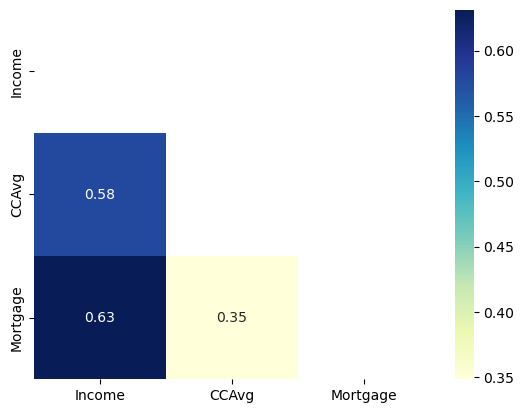

In [11]:
corr = mortgage_data[['Income','CCAvg','Mortgage']].corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, cmap="YlGnBu", annot=True)

<Axes: >

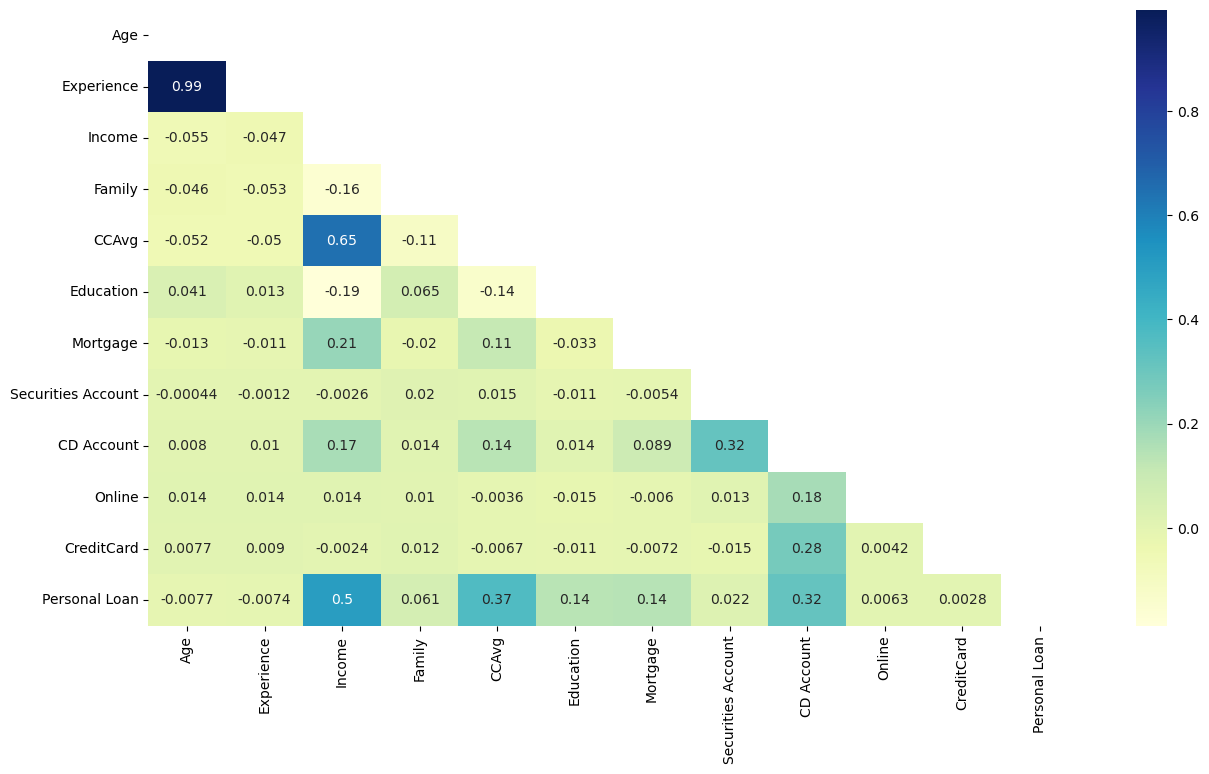

In [12]:
plt.figure(figsize=(15,8))


corr = data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, cmap="YlGnBu", annot=True)

Scatterplots:-

1. CCAvg vs Income
2. Income vs Mortgage
3. Income vs Personal Loan

<Axes: xlabel='Income', ylabel='Personal Loan'>

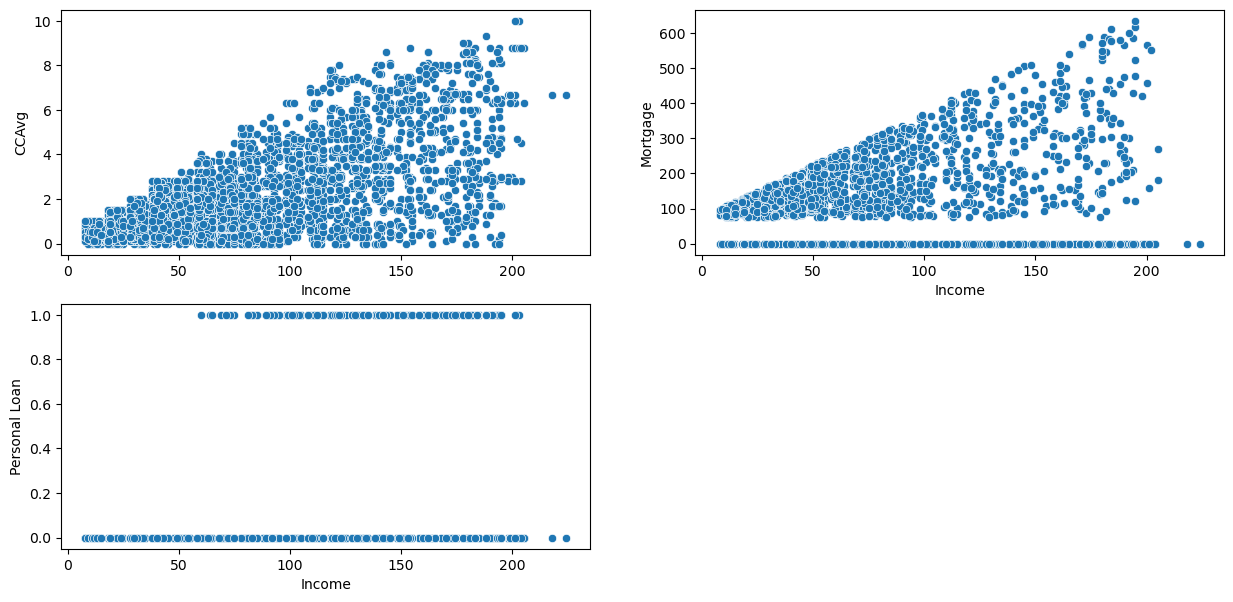

In [13]:
plt.figure(figsize=(15,7))

plt.subplot(2,2,1)
sns.scatterplot(x='Income',y='CCAvg',data=data)

plt.subplot(2,2,2)
sns.scatterplot(x='Income',y='Mortgage',data=data)

plt.subplot(2,2,3)
sns.scatterplot(x='Income',y='Personal Loan',data=data)

1. CCAvg and Mortgage are seen increasing with Income
2. **Only people whose income is above 50k took loan in the last campaign**  (Insight 1)

In [14]:
data[(data['CreditCard'] == 0) & (data['CCAvg']!=0)]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,25,1,49,4,1.6,1,0,1,0,0,0,0
1,45,19,34,3,1.5,1,0,1,0,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
5,37,13,29,4,0.4,2,155,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4994,64,40,75,3,2.0,3,0,0,0,1,0,0
4995,29,3,40,1,1.9,3,0,0,0,1,0,0
4996,30,4,15,4,0.4,1,85,0,0,1,0,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0


This can mean that the person uses some other CreditCard, which isn't issued by Universal Bank

# Univariate analysis

In [15]:
def kde_plotter(column,j):
    plt.subplot(2,2,j)
    print(sns.kdeplot(data[column]))
    j=j+1

Axes(0.125,0.53;0.352273x0.35)
Axes(0.547727,0.53;0.352273x0.35)
Axes(0.125,0.11;0.352273x0.35)
Axes(0.547727,0.11;0.352273x0.35)


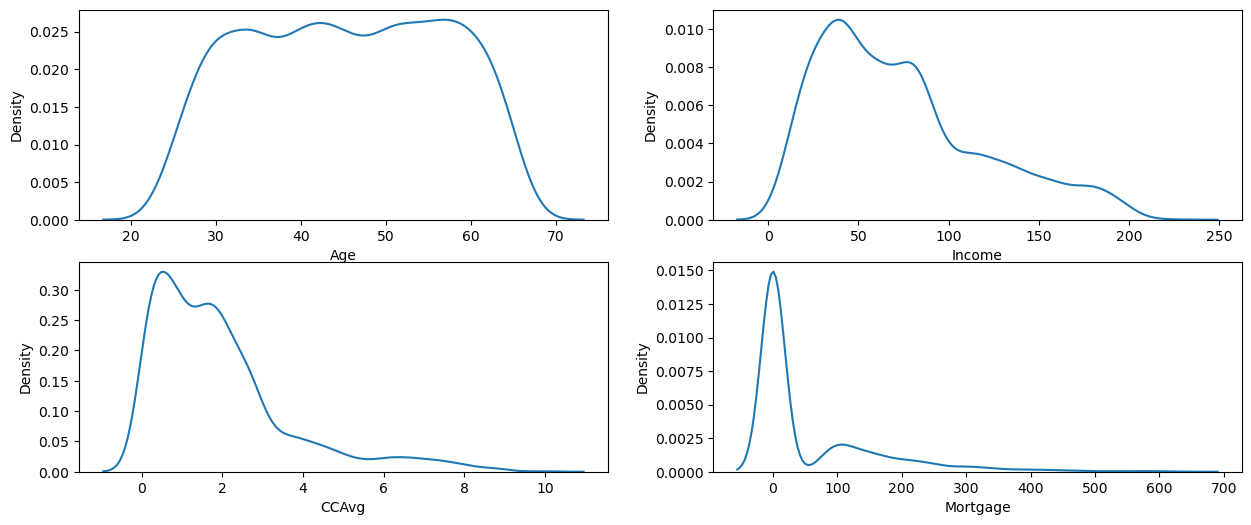

In [16]:
kde_columns = ['Age','Income','CCAvg','Mortgage']
j=0
plt.figure(figsize=(15,6))
for i in kde_columns:
    j=j+1
    kde_plotter(i,j)

Insights:- 

1) The depositors are mostly of the working class age (Ranging from **30 to 60**). There are very few people below 25 and above 60 (as seen by the steepness of the plot)
2) Income of most of the people lie in between **30k - 120k** (There are many people who earn above 100k, but their numbers are comparatively less)
3) Average CC Spending per month is **0.5k to 3k** for most of the people. It also goes as far as 8-9k for few 
4) The mortgage value for most of the people is nearly 0 (highly skewed at 0), and those who have a mortgage have it around **80k - 200k**, with very less people beyond that value (above 300k)

In [17]:
data[data['Mortgage']>300]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
42,32,7,132,4,1.1,2,412,0,0,1,0,1
59,31,5,188,2,4.5,1,455,0,0,0,0,0
66,62,36,105,2,2.8,1,336,0,0,0,0,0
112,40,15,82,3,1.0,1,309,0,0,0,0,0
119,32,7,112,1,4.6,1,366,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4844,31,6,81,2,2.5,1,313,0,0,0,0,0
4859,34,8,165,1,7.0,3,541,0,0,0,0,1
4865,50,24,133,4,1.4,2,342,0,0,0,1,1
4942,52,26,109,1,2.4,1,308,0,1,1,1,0


In [18]:
print(data[data['Mortgage']>300]['Income'].mean())
print(data[data['Mortgage']>300]['CCAvg'].mean())

print(data[data['Mortgage']<300].Income.mean())
print(data[data['Mortgage']<300].CCAvg.mean())

139.76119402985074
3.3
71.00145894122551
1.880547450326525


In [19]:
print(data[data['CD Account']==1]['Personal Loan'].value_counts())
data[data['CD Account']==0]['Personal Loan'].value_counts()

Personal Loan
0    162
1    140
Name: count, dtype: int64


Personal Loan
0    4358
1     340
Name: count, dtype: int64

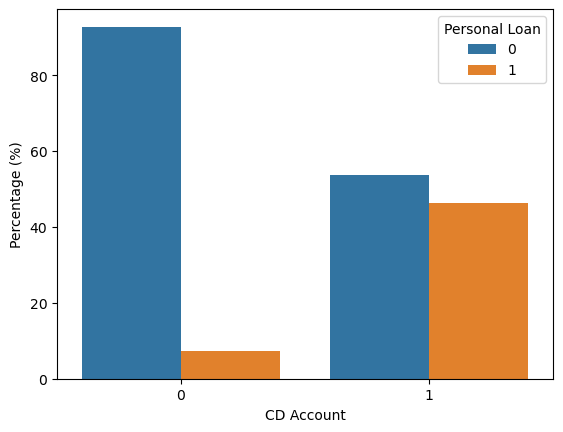

In [20]:
pct = (
    data.groupby('CD Account')['Personal Loan']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

sns.barplot(
    x='CD Account',
    y='Percentage',
    hue='Personal Loan',
    data=pct
)

plt.ylabel('Percentage (%)')
plt.show()

1. People with mortgages > 300 have on avergae almost **double the income** and also **higher CCAvg spending compared to others**
    However, they spend **less portion of their income on CC expenses** than others
2. **46%** of people with CD account took personal loan, while only **7%** of non-CD Account holders took loan. (Securities account did not make much difference, hence not included)   (Insight 2)

<Axes: xlabel='Experience', ylabel='Density'>

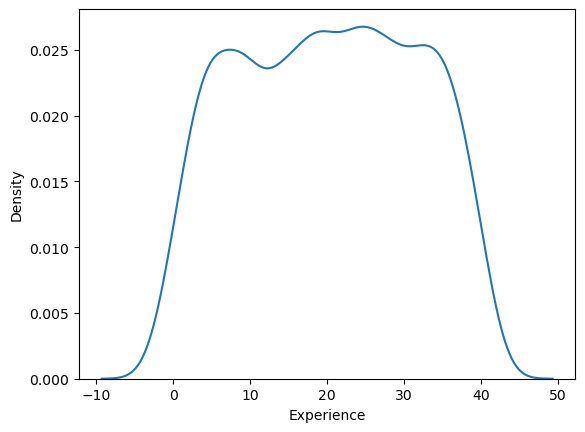

In [21]:
sns.kdeplot(data['Experience'])

In [22]:
data[data['Experience']<0]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
89,25,-1,113,4,2.300000,3,0,0,0,0,1,0
226,24,-1,39,2,1.700000,2,0,0,0,0,0,0
315,24,-2,51,3,0.300000,3,0,0,0,1,0,0
451,28,-2,48,2,1.750000,3,89,0,0,1,0,0
524,24,-1,75,4,0.200000,1,0,0,0,1,0,0
536,25,-1,43,3,2.400000,2,176,0,0,1,0,0
540,25,-1,109,4,2.300000,3,314,0,0,1,0,0
576,25,-1,48,3,0.300000,3,0,0,0,0,1,0
583,24,-1,38,2,1.700000,2,0,0,0,1,0,0
597,24,-2,125,2,7.200000,1,0,1,0,0,1,0


In [23]:
data = data[data['Experience'] >= 0]

# Experience cannot be negative, hence removed from the dataframe

1) Most depositors have an experience of 8 - 35 years

Checking age of people with very high experience to check there is no error (like entry errors in age or experience)

In [24]:
data[data['Experience']>40]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
14,67,41,112,1,2.0,1,0,1,0,0,0,0
88,65,41,51,2,1.1,1,0,0,0,1,0,0
99,66,41,15,3,0.1,3,0,0,0,1,0,0
254,65,41,134,3,3.9,3,121,0,0,1,0,1
257,66,41,18,3,0.5,1,0,0,0,0,1,0
382,65,41,133,4,2.0,1,0,0,0,0,1,1
465,66,42,35,1,1.9,2,172,0,0,1,0,0
662,65,41,185,3,2.0,2,0,0,0,0,0,1
668,66,41,18,3,0.5,1,0,0,0,0,0,0
671,65,41,105,1,3.0,2,282,1,1,1,0,1


No error about that

Family, Education, Securities Account, CD account, CreditCard, Personal Loan

In [25]:
Categorical_col = ['Family', 'Education', 'Securities Account', 'CD Account', 'CreditCard', 'Online','Personal Loan']

In [26]:
for col in Categorical_col:
    data[col] = data[col].astype('category')

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4948 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 4948 non-null   int64   
 1   Experience          4948 non-null   int64   
 2   Income              4948 non-null   int64   
 3   Family              4948 non-null   category
 4   CCAvg               4948 non-null   float64 
 5   Education           4948 non-null   category
 6   Mortgage            4948 non-null   int64   
 7   Securities Account  4948 non-null   category
 8   CD Account          4948 non-null   category
 9   Online              4948 non-null   category
 10  CreditCard          4948 non-null   category
 11  Personal Loan       4948 non-null   category
dtypes: category(7), float64(1), int64(4)
memory usage: 266.7 KB


<Axes: xlabel='Education'>

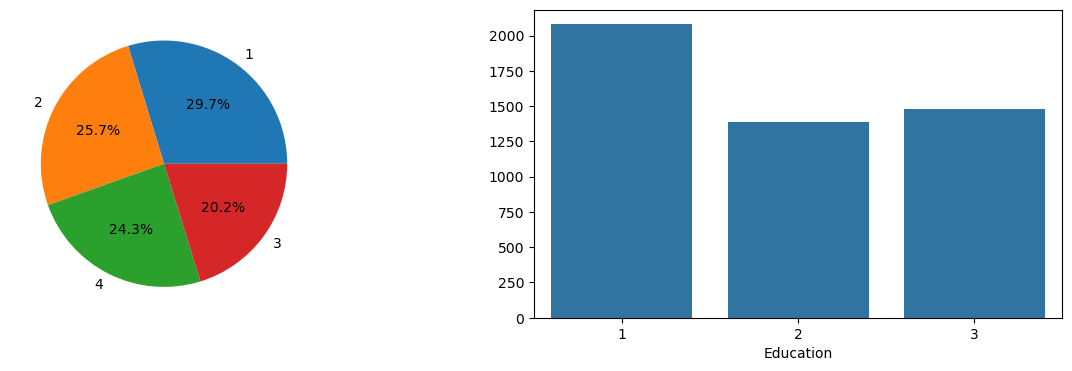

In [28]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.pie(data['Family'].value_counts(), labels=data['Family'].value_counts().index, autopct='%1.1f%%')

plt.subplot(1,2,2)

sns.barplot(
    x=data['Education'].value_counts().index,
    y=data['Education'].value_counts().values
)

1. Approximately **30%** of depositors are without spouse and children  (Single Individuals). **25%** of them are married but have no children (Couple without kid(s)). The rest of the **almost 45%** of them are married and have children (Family with kids)
2. Majority of the people have completed their education till Undergraduation, with almost equal number of people being graduates and professionals

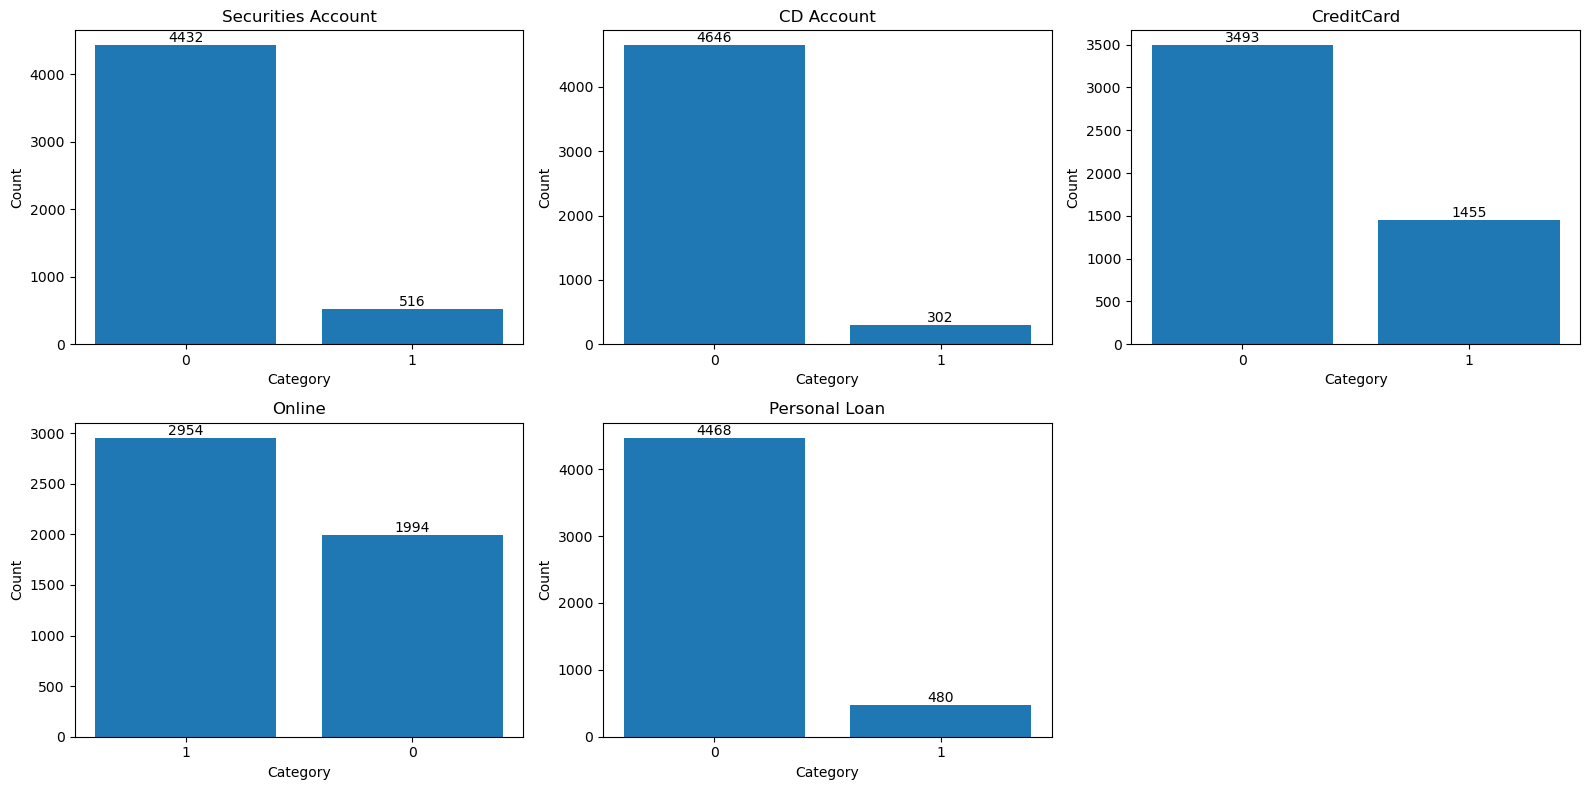

In [29]:
cols = ['Securities Account', 'CD Account', 'CreditCard', 'Online', 'Personal Loan']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(cols):
    vc = data[col].value_counts()
    
    bars = axes[idx].bar(vc.index.astype(str), vc.values)
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Category")
    axes[idx].set_ylabel("Count")
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom',
            fontsize=10
        )
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

6% of total depositors have a CD account

10% of total depositors have a Securities account

In [30]:
data[(data['Securities Account']==1) & (data['CD Account']==1)]['Age'].count()

147

In [31]:
print(data[data['Online']==1]['Age'].describe())

count    2954.000000
mean       45.683142
std        11.328656
min        24.000000
25%        36.000000
50%        46.000000
75%        56.000000
max        67.000000
Name: Age, dtype: float64


In [32]:
print(data[data['Online']!=1]['Age'].describe())

count    1994.000000
mean       45.370612
std        11.309253
min        24.000000
25%        36.000000
50%        45.000000
75%        55.000000
max        67.000000
Name: Age, dtype: float64


In [33]:
print(data[(data['Age']>40) & (data['Age']<50)]['Online'].value_counts())
print(data[data['Age']>60]['Online'].value_counts())

Online
1    648
0    484
Name: count, dtype: int64
Online
1    328
0    219
Name: count, dtype: int64


1. Security account only :- **375** , CD account only :- **155** , Security and CD account both :- **147** , None :- **4323**
2. **Approximately 30%** hold CreditCard issued by Universal bank
3. Around **60%** of people use online services. Age doesn’t really seem to matter — **60%** of people over 60 and **57%** of people in their 40s use the online services . The describe stats back this up too (Similar mean age, Similar standard deviation)
5. Only **10%** of the depositors took the loan offered in the last campaign

# Feature engineering

In [34]:
data.Age.min()

24

In [35]:
# Age Group , MortgageCategory , Monthly income, IncometoCCRatio (Monthly income/CCAvg)


data['AgeGroup'] = pd.cut(data['Age'], 
                          bins= [20,30,40,50,60,100],
                          labels=['20-30', '30-40', '40-50','50-60' ,'60+'], 
                          right=False)

data['MortgageCategory'] = pd.cut(data['Mortgage'],
                                  bins= [0,1,80,300,700],
                                  labels = ['None','Low','Normal','High'],
                                  right=False)

data['MonthlyIncome'] = data['Income'] / 12

data['CCToIncomeRatio'] = data['CCAvg'] / data['MonthlyIncome']

In [36]:
data.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard',
       'Personal Loan', 'AgeGroup', 'MortgageCategory', 'MonthlyIncome',
       'CCToIncomeRatio'],
      dtype='object')

In [37]:
data = data[['Age','AgeGroup','Experience', 'Income','MonthlyIncome', 'Family', 'CCAvg',
       'Education', 'Mortgage','MortgageCategory','Securities Account', 'CD Account', 'Online',
       'CreditCard','CCToIncomeRatio','Personal Loan']]

In [38]:
data.sample(3)

,Age,AgeGroup,Experience,Income,MonthlyIncome,Family,CCAvg,Education,Mortgage,MortgageCategory,Securities Account,CD Account,Online,CreditCard,CCToIncomeRatio,Personal Loan
1604,55,50-60,29,111,9.250000,2,3.6,3,0,None,0,0,0,1,0.389189,1
1862,42,40-50,17,82,6.833333,1,3.7,3,0,None,0,0,1,0,0.541463,0
679,55,50-60,31,103,8.583333,3,1.8,2,364,High,0,0,0,0,0.209709,0


# Bivariate EDA

1. Avg Income of diff AgeGroup People

Axes(0.125,0.11;0.775x0.77)


AgeGroup
50-60    26.68
40-50    25.14
30-40    24.94
60+      13.48
20-30     8.72
Name: count, dtype: float64

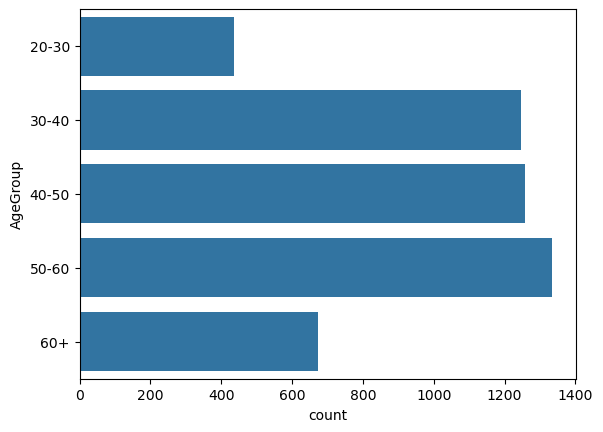

In [39]:
print(sns.countplot(data['AgeGroup']))

data.AgeGroup.value_counts() / 50

[Text(0, 0, '80.3142'),
 Text(0, 0, '74.8661'),
 Text(0, 0, '76.5943'),
 Text(0, 0, '69.3283'),
 Text(0, 0, '71.3591')]

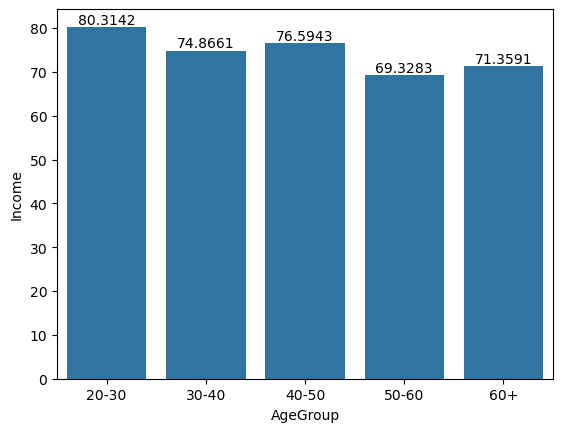

In [40]:
ax = sns.barplot(x='AgeGroup',y='Income',data=data,errorbar=None)

ax.bar_label(ax.containers[0])

Income is almost consistent among the age groups, except older people who earn just a little less

In [41]:
data.groupby('AgeGroup',observed=True)['Mortgage'].mean()

AgeGroup
20-30    61.908257
30-40    57.529270
40-50    55.359586
50-60    56.446777
60+      54.316024
Name: Mortgage, dtype: float64

<Axes: xlabel='AgeGroup', ylabel='count'>

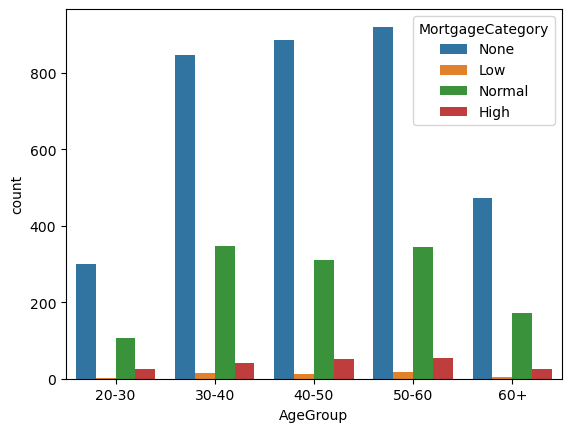

In [42]:
# Mortgage categorization by age group    (None,Low,Normal,High Mortgage in each age group)

sns.countplot(x='AgeGroup',hue='MortgageCategory',data=data)

There are mostly people who have a normal category Mortgage (seen in all groups) (of the ones who have mortgages)

**Highest High mortgagers are aged 40-50 and 50-60, which is due to the fact that they are more in numbers**

In [43]:
data['IncomeLevel'] = pd.cut(data['Income'], 
                          bins= [0,60,130,300],
                          labels=['Low','Normal', 'High'], 
                          right=False)

In [44]:
data.columns

Index(['Age', 'AgeGroup', 'Experience', 'Income', 'MonthlyIncome', 'Family',
       'CCAvg', 'Education', 'Mortgage', 'MortgageCategory',
       'Securities Account', 'CD Account', 'Online', 'CreditCard',
       'CCToIncomeRatio', 'Personal Loan', 'IncomeLevel'],
      dtype='object')

In [45]:
data = data[['Age', 'AgeGroup', 'Experience', 'Income','IncomeLevel','MonthlyIncome', 'Family',
       'CCAvg', 'Education', 'Mortgage', 'MortgageCategory',
       'Securities Account', 'CD Account', 'Online', 'CreditCard',
       'CCToIncomeRatio', 'Personal Loan']]

In [46]:
data.IncomeLevel.value_counts()

IncomeLevel
Low       2256
Normal    1973
High       719
Name: count, dtype: int64

In [47]:
data.MortgageCategory.value_counts()

MortgageCategory
None      3422
Normal    1276
High       200
Low         50
Name: count, dtype: int64

C:\Users\bhavy\AppData\Local\Temp\ipykernel_8624\3870504061.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('IncomeLevel')['MortgageCategory']


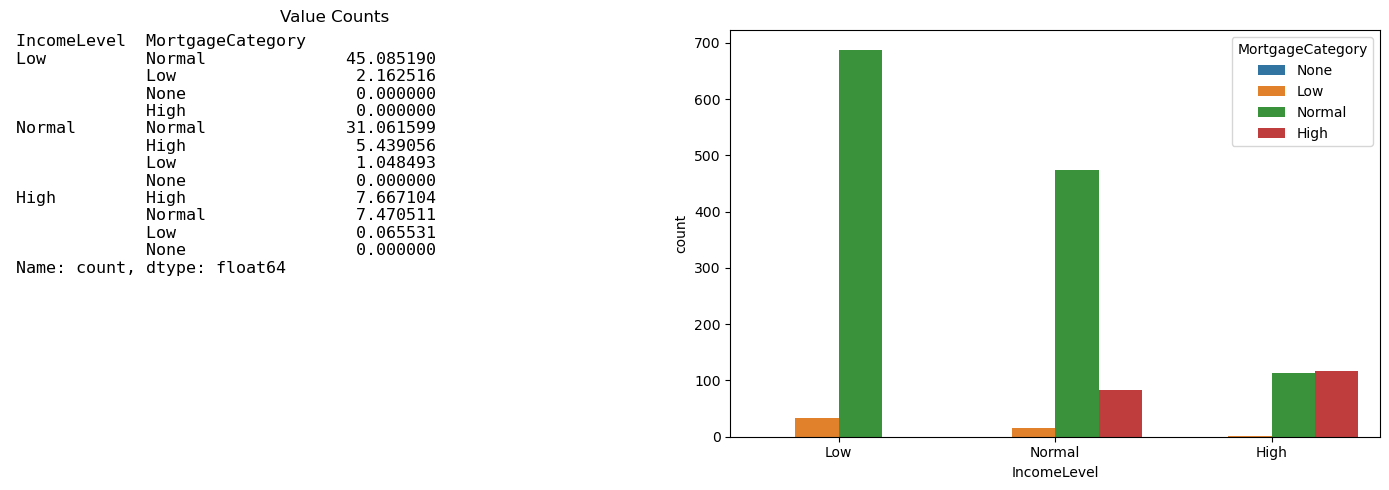

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

text = str(
    data[data['MortgageCategory']!='None']
        .groupby('IncomeLevel')['MortgageCategory']
        .value_counts() / 15.26
)

ax[0].text(0.01, 0.99, text, fontsize=12, va='top', family='monospace')
ax[0].axis('off')
ax[0].set_title("Value Counts")

sns.countplot(
    x='IncomeLevel',
    hue='MortgageCategory',
    data=data[data['MortgageCategory']!='None'],
    ax=ax[1]
)

plt.tight_layout()
plt.show()

Out of the people who have mortgages, 

1. **45%** of Low income, **31%** of Normal income and only **7%** of High income people have Normal Mortgage
2. Obviously, most of the high mortgages were of people with high income
3. Most mortgages are of people with low incomes

In [49]:
data.groupby('MortgageCategory')['Personal Loan'].value_counts()

C:\Users\bhavy\AppData\Local\Temp\ipykernel_8624\2304939076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('MortgageCategory')['Personal Loan'].value_counts()


MortgageCategory  Personal Loan
None              0                3110
                  1                 312
Low               0                  48
                  1                   2
Normal            0                1186
                  1                  90
High              0                 124
                  1                  76
Name: count, dtype: int64

**38%** of High Mortgagers took personal loan, and most high mortgages were taken by people with High income  (**Insight 3**)

In [50]:
# Lets see how many of these high mortgagers have CD account and how many of them took personal loans (security account doesn't affect much as seen
#  earlier, hence not included

High_mortgagers = data[data['MortgageCategory']=='High']

In [51]:
print('High Mortgagers with a CD Account')
print(High_mortgagers[High_mortgagers['CD Account']==1]['Personal Loan'].value_counts())


print('High Mortgagers without a CD Account')
High_mortgagers[High_mortgagers['CD Account']==0]['Personal Loan'].value_counts()

High Mortgagers with a CD Account
Personal Loan
1    27
0     8
Name: count, dtype: int64
High Mortgagers without a CD Account


Personal Loan
0    116
1     49
Name: count, dtype: int64

**77%** of high mortgagers with CD Account took loan, while **approximately 30%** of high mortgagers without CD account took loan (**Insight 3 continued**)

In [52]:
# How much of the monthly income of high mortgagers go into Credit Card expense  (can see ratio)

High_mortgagers['CCToIncomeRatio'].describe()

count    200.000000
mean       0.281475
std        0.181567
min        0.000000
25%        0.130830
50%        0.254431
75%        0.413150
max        0.793220
Name: CCToIncomeRatio, dtype: float64

Approximately **28%** of the income of high mortgagers goes into Credit card expenses, with a standard deviation of about **18%**

**It means that high mortgagers are actively using CreditCards**

This, in a way, rejects the hypothesis that people with high mortgage and high CC expense have lower chances of taking a loan

# CreditCard EDA

In [53]:
# Avg spend of people with Universalbank's CreditCard and of people with CreditCard of some other bank  (for those who spend)

CC_data = data[data['CCAvg'] > 0]

In [54]:
print(CC_data.groupby('CreditCard',observed=False)['CCAvg'].mean())

CC_data.groupby('CreditCard',observed=False)['CCToIncomeRatio'].mean()

CreditCard
0    1.988624
1    1.953527
Name: CCAvg, dtype: float64


CreditCard
0    0.340027
1    0.336894
Name: CCToIncomeRatio, dtype: float64

People spend the same, which means there is not much difference between Universal Bank's credit card and other credit card

In [55]:
CC_data.shape

(4842, 17)

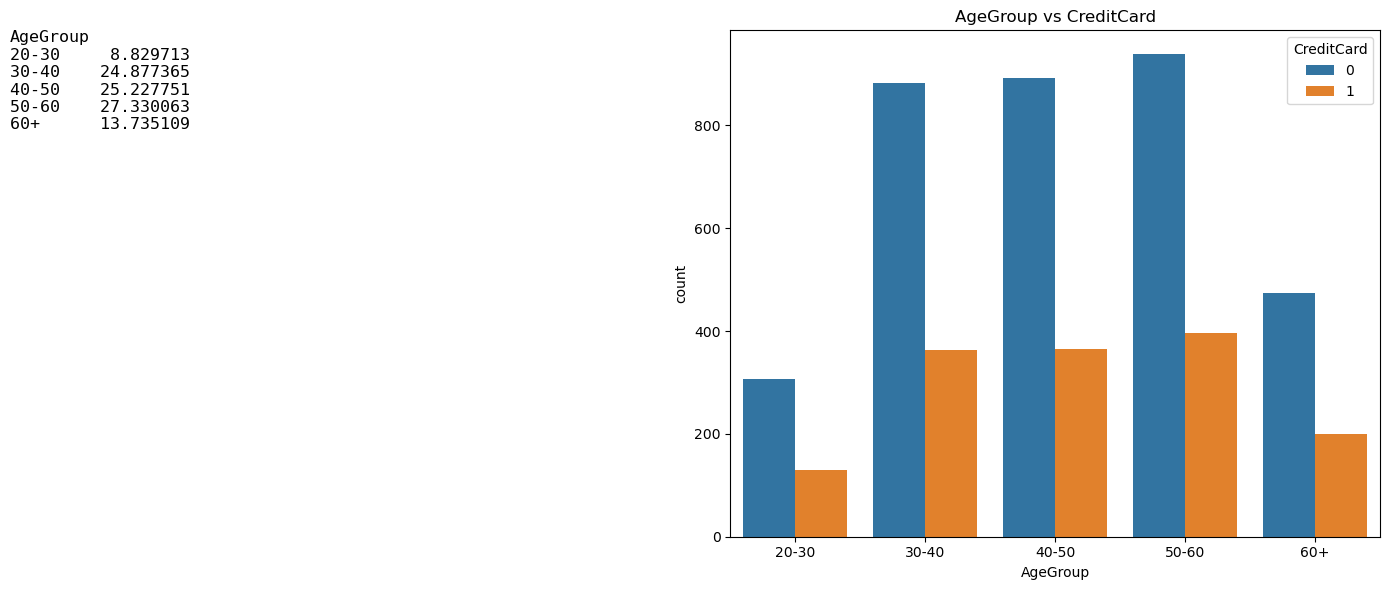

In [56]:
# Age Group vs Credit Card. How many of them have Universal Bank's credit card

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vc = CC_data[CC_data.CreditCard==1]['AgeGroup'].value_counts().sort_index() / 14.27

axes[0].axis('off')
text = vc.to_string()
axes[0].text(0, 1, text, fontsize=12, va='top', family='monospace')

sns.countplot(x='AgeGroup', hue='CreditCard', data=data, ax=axes[1])
axes[1].set_title("AgeGroup vs CreditCard")

plt.tight_layout()
plt.show()

Out of all 4842 CreditCard users (with CCAvg > 0), 1427 use CC of Universal Bank

Out of this 1427, **almost 75%** are **aged 30-60**

In [57]:
df[['CreditCard','Personal Loan']].corr()

,CreditCard,Personal Loan
CreditCard,1.000000,0.002802
Personal Loan,0.002802,1.000000


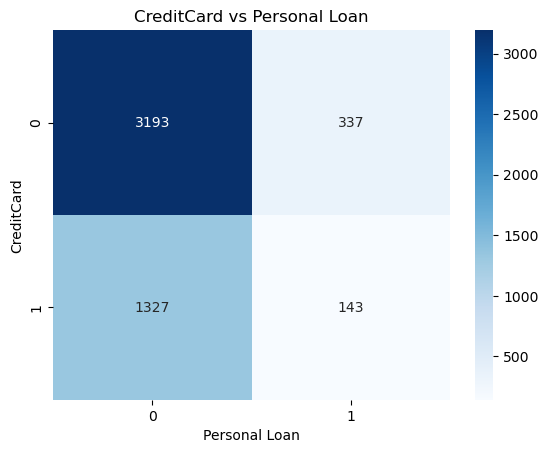

In [58]:
ct = pd.crosstab(df['CreditCard'], df['Personal Loan'])

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title("CreditCard vs Personal Loan")
plt.show()

**This insights show that CreditCard and Personal Loan are not related, hence should not be considered in taking actions for the business**

However,

**Customers aged 30–60 are the ones with the most number of credit cards. This shows that they are active with the bank finanacially. This makes them a stronger segment for targeted engagement campaigns, but not for this one**

In [59]:
data[data['CCToIncomeRatio'] >=1]

,Age,AgeGroup,Experience,Income,IncomeLevel,MonthlyIncome,Family,CCAvg,Education,Mortgage,MortgageCategory,Securities Account,CD Account,Online,CreditCard,CCToIncomeRatio,Personal Loan
2,39,30-40,15,11,Low,0.916667,1,1.000000,1,0,None,0,0,0,0,1.090909,0
50,32,30-40,8,8,Low,0.666667,4,0.700000,2,0,None,1,0,1,0,1.050000,0
110,41,40-50,14,9,Low,0.750000,3,1.000000,2,0,None,0,0,0,0,1.333333,0
291,43,40-50,16,8,Low,0.666667,3,0.666667,2,88,Normal,0,0,1,0,1.000000,0
563,51,50-60,27,12,Low,1.000000,4,1.000000,1,0,None,0,0,1,0,1.000000,0
633,61,60+,31,18,Low,1.500000,1,1.500000,3,0,None,0,0,1,1,1.000000,0
933,50,50-60,23,9,Low,0.750000,2,1.000000,2,0,None,0,0,1,0,1.333333,0
999,60,60+,35,18,Low,1.500000,1,1.500000,2,0,None,0,0,1,1,1.000000,0
1000,59,50-60,35,8,Low,0.666667,4,0.700000,1,91,Normal,1,0,0,0,1.050000,0
1979,41,40-50,17,11,Low,0.916667,1,1.000000,1,0,None,0,0,0,0,1.090909,0


**People who spend more on CC than their income**

# Education EDA

1. How much do each category spend on CreditCards and whats their CCToIncomeRatio (which can then be hued by CreditCard of our bank or other)
2. Highly educated people have a higher chance of having a securities account? (Hypothesis) (Check by looking Securities value counts by each ed. cat.)
3. Income for each category
4. In each category, how much % of people took loan

In [60]:
data.Education.value_counts()

Education
1    2080
3    1481
2    1387
Name: count, dtype: int64

<Axes: xlabel='Education', ylabel='CCToIncomeRatio'>

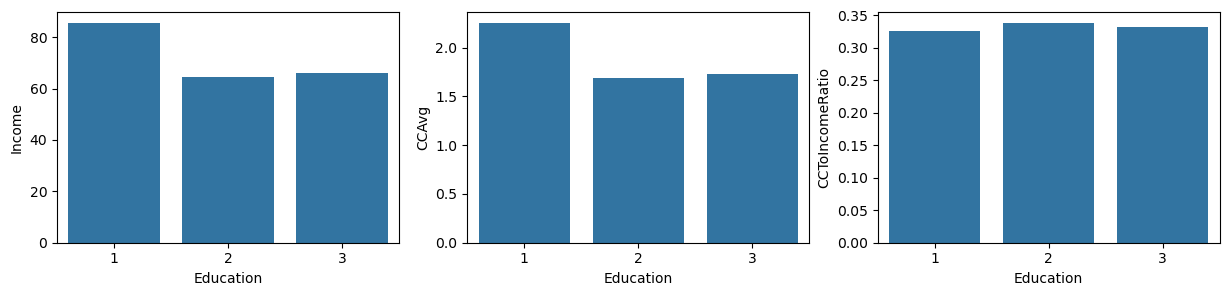

In [61]:
plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
sns.barplot(x='Education',y='Income',data=data,errorbar=None)

plt.subplot(1,3,2)
sns.barplot(x='Education',y='CCAvg',data=data,errorbar=None)

plt.subplot(1,3,3)
sns.barplot(x='Education',y='CCToIncomeRatio',data=data,errorbar=None)

1. Undergrad people earn more on average than Graduates and Advanced people. They also spend higher on CreditCards. However, the CCToIncomeRatio is almost same for each category

<Axes: xlabel='Education', ylabel='CCAvg'>

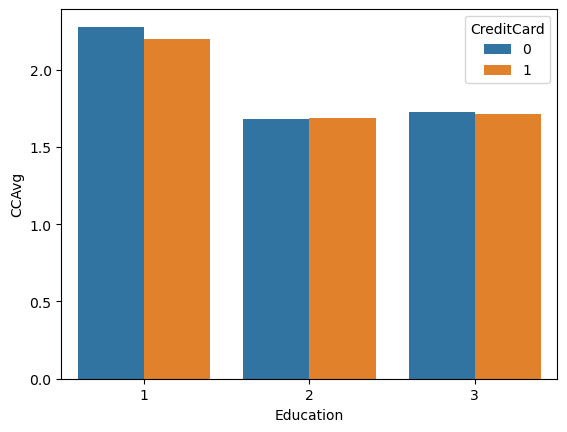

In [62]:
sns.barplot(x='Education',y='CCAvg',hue='CreditCard',data=data,errorbar=None)

It does not matter which card they have, Average expense is equal within each level of education

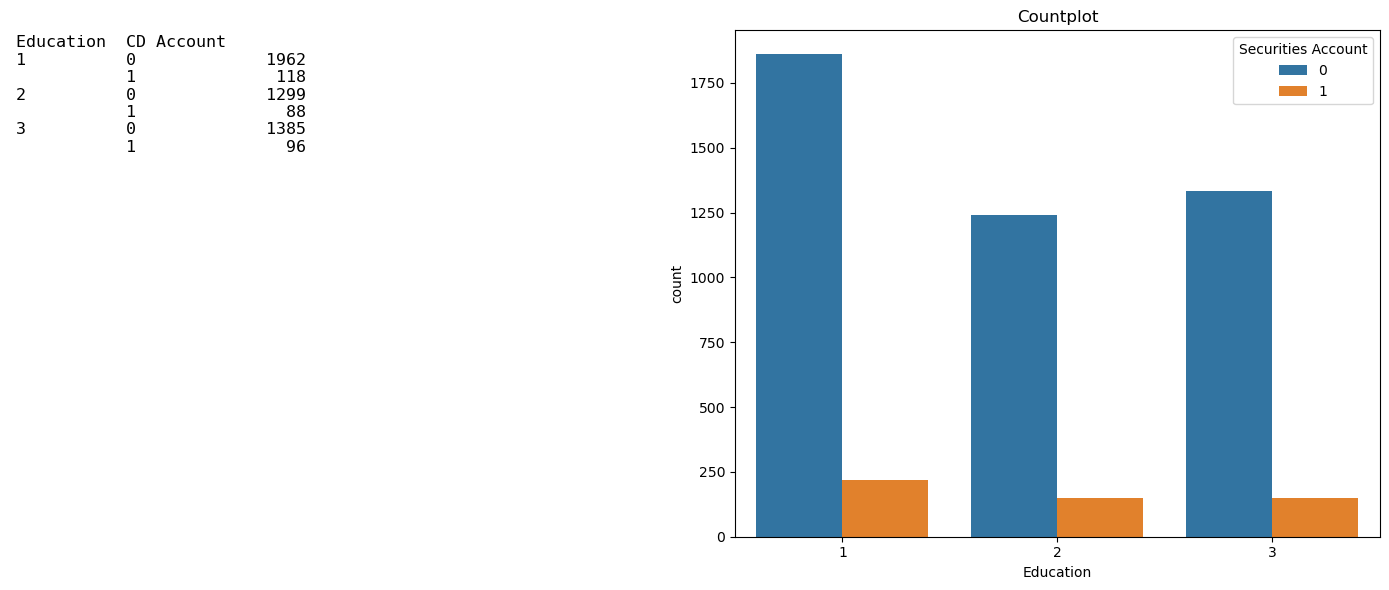

In [63]:
vc = data.groupby(['Education','CD Account'], observed=False)['Education'].count()
vc_text = vc.to_string()

plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
plt.text(0.01, 0.99, vc_text, va='top', family='monospace', fontsize=12)
plt.xticks([]); plt.yticks([])
plt.box(False)

plt.subplot(1,2,2)
sns.countplot(x='Education', hue='Securities Account', data=data)
plt.title("Countplot")

plt.tight_layout()
plt.show()

Approximately 6% of people in all levels of education have a CD account

In [64]:
# How many in each level of took loan

data.groupby('Education')['Personal Loan'].value_counts()

C:\Users\bhavy\AppData\Local\Temp\ipykernel_8624\2221382997.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Education')['Personal Loan'].value_counts()


Education  Personal Loan
1          0                1987
           1                  93
2          0                1205
           1                 182
3          0                1276
           1                 205
Name: count, dtype: int64

1. **4.5%** people of Education level 1 , and **approximately 14%** of people with education level 2 and 3 (each) took loan
2. Out of all the loan takers, only **20%** of them were with Education level 1, while the rest **80%** were taken by people with Education level 2 and 3

*Lets take a look at the Education level of people aged 40-60, our prime targets for the next campaign (since they're the ones with higher number of people with high mortgages)*

In [65]:
Aged_40_to_60 = data[(data['Age']>=40) & (data['Age']<=60)]

In [66]:
Aged_40_to_60['Education'].value_counts().sort_index()

Education
1    1160
2     715
3     843
Name: count, dtype: int64

**42%** of people aged 40-60 are Undergraduates, while the rest **58%** are graduates or professionals

42-58 is not so big difference in a ratio, but it still is significant

In [67]:
# Lets see how many people aged 40-60 took a loan, separated by the Education level

Aged_40_to_60.groupby('Personal Loan',observed=False)['Education'].value_counts().sort_index()

Personal Loan  Education
0              1            1107
               2             622
               3             744
1              1              53
               2              93
               3              99
Name: count, dtype: int64

We see the same pattern here too with people aged 40-60

Out of all loan takers, 20% were Undergraduates, while the rest 80% were Graduates/Professionals

Hence we can conclude that bank should focus more on depositors who are Graduates/Professionals (higher conversion rate)  **(Insight 4)**

# Family EDA

In [68]:
data.Family.value_counts().sort_index()

Family
1    1470
2    1274
3    1001
4    1203
Name: count, dtype: int64

In [69]:
data.groupby('Family',observed=False)['Personal Loan'].value_counts()

Family  Personal Loan
1       0                1363
        1                 107
2       0                1168
        1                 106
3       0                 868
        1                 133
4       0                1069
        1                 134
Name: count, dtype: int64

1. Out of all the loan takers, **44%** had a family size of 1 or 2, and **56%** were a family of 3 or 4.
2. Roughly **8%** of people with family size of 1 or 2 took personal loan in the last campaign, and roughly **12%** of people with family size 3 or 4 took loan, which is not a significant difference, since overall 10% of people had taken loan in the last campaign

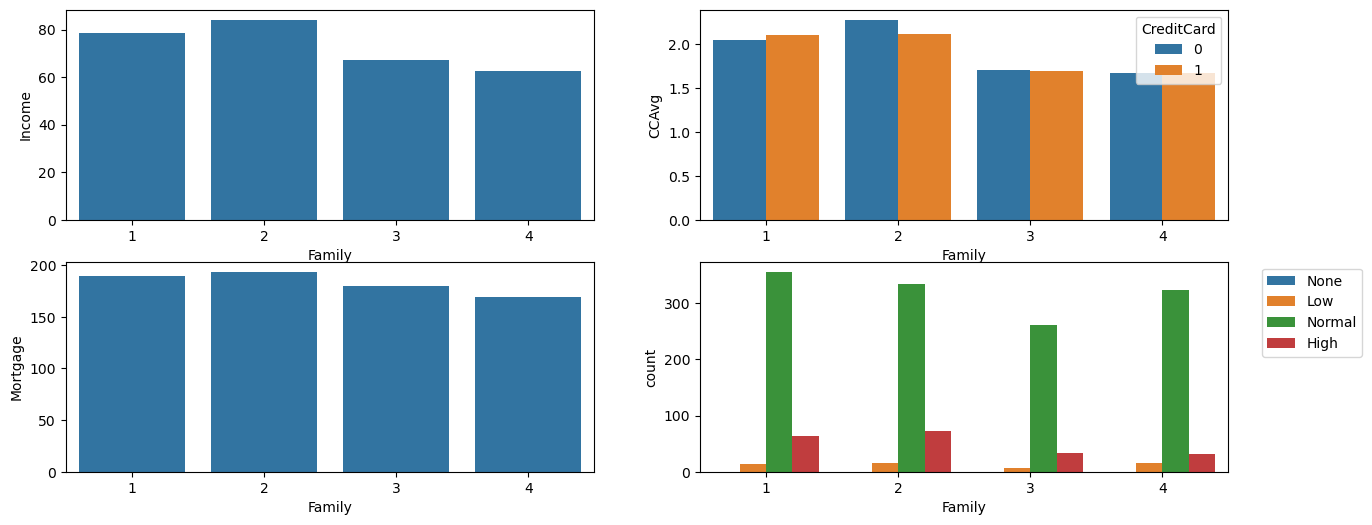

In [70]:
plt.figure(figsize=(15,6))

plt.subplot(2,2,1)
sns.barplot(x='Family',y='Income',data=data,errorbar=None)

plt.subplot(2,2,2)
sns.barplot(x='Family',y='CCAvg',hue='CreditCard',data=data,errorbar=None)

plt.subplot(2,2,3)
sns.barplot(x='Family',y='Mortgage',data=data[data['MortgageCategory']!='None'],errorbar=None)

plt.subplot(2,2,4)
sns.countplot(x='Family',hue='MortgageCategory',data=data[data['MortgageCategory']!='None'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

1. Family size of 2 has the highest income on average, and so is their Average spending on CreditCard per month (Issued by Universal Bank or other)
2. Out of people with mortgages, highest average mortgage is of people with family size of 2. They are also the highest with high mortgages

<Axes: xlabel='Family', ylabel='count'>

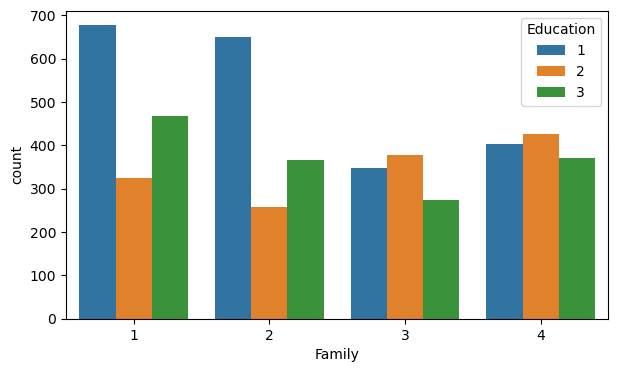

In [71]:
plt.figure(figsize=(7,4))
sns.countplot(x='Family',hue='Education',data=data)

In [72]:
data['FamSize'] = data['Family'].apply(lambda x: 'Small' if x in [1, 2] else 'Big')

In [73]:
data.groupby('FamSize',observed=False)['CCToIncomeRatio'].mean()

FamSize
Big      0.333759
Small    0.330297
Name: CCToIncomeRatio, dtype: float64

In [74]:
data.groupby('FamSize',observed=False)['Personal Loan'].value_counts()

FamSize  Personal Loan
Big      0                1937
         1                 267
Small    0                2531
         1                 213
Name: count, dtype: int64

Big families have a higher chance of taking a loan, but its not huge difference, hence should not be much focused on

# Online EDA

1. % of people who took loan (hue='Online')
2. After seeing loan % for Online and Not-Online, check how many have CD account

In [75]:
data.groupby('Online',observed=False)['Personal Loan'].value_counts()

Online  Personal Loan
0       0                1805
        1                 189
1       0                2663
        1                 291
Name: count, dtype: int64

9% of people (for both, who use and don't use online services) took loans, hence Online does not affect if one takes loan or not

<Axes: xlabel='Online', ylabel='count'>

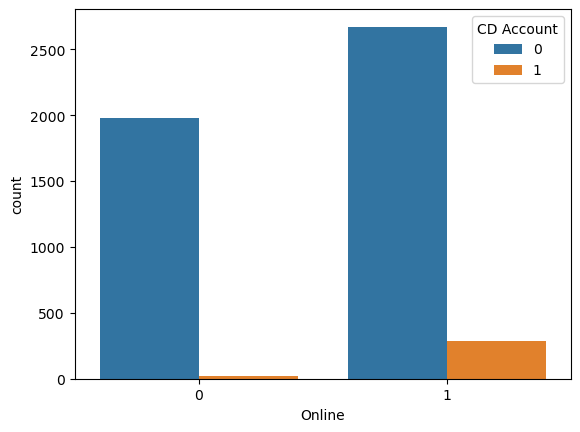

In [76]:
sns.countplot(x='Online',hue='CD Account',data=data)

Almost all people who have CD account in the bank uses its Online services

Hence, we can reach out to them (CD account holders) for campaigning by Online services  **(Insight 2 continued)**

In [77]:
data.groupby('Online',observed=True)['CCAvg'].mean()

Online
0    1.943313
1    1.930896
Name: CCAvg, dtype: float64

People tend to spend the same, irrespective whether they use Online services or not

In [78]:
data.groupby(['Personal Loan'],observed=True)['AgeGroup'].value_counts().sort_index()

Personal Loan  AgeGroup
0              20-30        387
               30-40       1120
               40-50       1140
               50-60       1216
               60+          605
1              20-30         49
               30-40        127
               40-50        117
               50-60        118
               60+           69
Name: count, dtype: int64

In [79]:
data[data['Personal Loan']==1]['CCAvg'].mean()

3.9053472222222223

In [80]:
data[data['Personal Loan']==0]['CCAvg'].mean()

1.7243210981796477

People who took loan have higher spending on CC

# Business actions that can be taken

1. *No need to campaign much to people having income less than 50k (no one with income below 50k took personal loan)*
2. *Prioritize people with a CD Account (6.5x more likely to take a loan)* (46% CD acc holders took loan, while only 7% of those who did not have CD Account took loan. *Moreover, almost all CD holders use online services, hence they can be campaigned on the online services*
3. *Focus more on people with high mortgages (who are mostly people with high income. They are also mostly aged 40-60)*
   - Furthermore, out of these high mortgagers, 77% of people who held a CD Account and 30% of people who didn't hold CD Account took personal loan
4. *Customers who are graduates/professionals are more likely to take loan than undergraduates* (Out of all loan takers, 80% had education = 2 or 3, even though there are higher number of people with Education level 1.

Groups to focus on:-

1. Income > 50
2. People aged 30-60
3. CD Account holders
4. High mortgagers (who also happen to be people with high income)
   - CD Account holders > No CD Account holders within High mortgagers
5. Graduates and professionals

Features thought to be important for prediction by EDA:-

Income, Age, CDAccount, Mortgage, Education, CCAvg, CCToIncomeRatio